In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima_process import ArmaProcess\
#! pip install pycausalimpact # устанавливаем библиотеку pycausalimpact
from causalimpact import CausalImpact
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import statsmodels.api as sm
from scipy.stats import ttest_1samp
from itertools import combinations
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

## Домашка:

#### Описание
Вы продуктовый аналитик в классифайде. В компанию пришел новый дизайнер и предложил освежить дизайн и добавить анимацию при сохранении объявления в избранное. Ваша задача, проследить за целевой метрикой (конверсией из просмотра объявления в сохранение объявления в избранное). Основной риск - эта метрика может сократится.

Изменения планируются ввести сначала в одной платформе (IOS), а затем на других, если гипотеза о том что конверсия не упадет, подтвердится. Поэтому мы можем попробовать применить здесь causal inference без рандомизированных тестов.

#### Данные

Работать будем с таблицей dm_user_events в clickhouse

Нас интересует три типа событий из этой таблицы:
- cnt_add_to_favorites - Сохранение в избранное
- cnt_view_advertisement - Просмотры объявления
- cnt_display_phone - кол-во показов телефона продавца (когда покупатель смотрит на карточке продавца его контактный телефон)


#### Задачи:

**1) ВЫГРУЗКА ДАННЫХ**
- 1.1 Выгрузите из clickhouse по дням и платформам метрику отношения из просмотра объявлении в сохранение в избранное по событиям, за период 01.02.2022 - 15.07.2022. Т.е. нужно на каждый день и платформу достать сумму событий cnt_add_to_favorites, сумму событий cnt_view_advertisement и найти отношение первого ко второму (для удобства сравнения с моим кодом-решения назовтие эту метрику 'cr')

- 1.2 Также тем же запросом выгрузите по дням и платформам сумму событий cnt_display_phone - мы предполагаем, что эта метрика может быть хорошей ковариатой, поэтому достанем и ее.

**Итоговый датасет должен иметь схему:**
- event_date - дата аггрегации
- platform - платформа совершения события
- cnt_fav - кол-во событий добавления в избранное
- cnt_view - кол-во просмотра объявлений
- cnt_display_phone - кол-во просмотра номеров телевона
- cr - отношение

**2) АГГРЕГИРУЙТЕ ДАТАСЕТ** по дням. Где одна строка датасета - один день, а по столбцам - метрики. На каждую комбинацию (платформа-метрика) отдельный столбец. Постройте график динамики метрики cr в разрезе платформ.
- 2.1 Укажите среднюю по целевой метрике отношения в платформе IOS ('cr_ios') по дням до нововведения (меньше '2022-07-01')
- 2.2 Укажите среднюю по целевой метрике отношения в платформе IOS ('cr_ios') по дням после нововведения (>= '2022-07-01')

**3) ПОСТРОЙТЕ КОРРЕЛЯЦИОННУЮ МАТРИЦУ**
Матрицу нужно строить по pre данным
- 3.1. Найдите 3 наиболее скоррелированные с целевой метрикой сr_ios (именно в IOS у нас было воздействие).

**4) ПРОВЕДИТЕ РАЗОВЫЙ CAUSAL IMPACT АНАЛИЗ** на метрику cr_ios и тремя лучшими мтериками ковариатами, где днем intervention является 2022-07-01 (именно в этот день зарелизили новый дизайн блок Избранные объявления.
- 4.1. Отвергается ли нулевая гипотеза?
- 4.2. Какой относительный размер эффекта находит модель?

**5) ПРОВЕДИТЕ АНАЛИЗ КОЭФФИЦИЕНТОВ МОДЕЛИ**
- 5.1. Какие элементы регрессионого уравнения имеют p-value < 0.05?

**6) ПРОВЕДИТЕ АНАЛИЗ ОСТАТКОВ МОДЕЛИ**

6.1. Укажите верные утверждения по 3 гипотезам относително остатков
- остатки стационарны?: -Да? Нет?
- остатки смещены?: -Да? Нет?
- остатки автокоррелирвоаны?: -Да? Нет?

**7) ОЦЕНИТЕ ТОЧНОСТЬ ПРОГНОЗА МОДЕЛИ ПО ИСТОРИЧЕСКИМ ДАННЫМ**
- Укажите MAE
- Укажите MAPE
- Укажите R2_score

**8) Оценка мощности и стат значимости causal impact**

**Для симуляции будем использовать следующие вводные**
1) три ковариаты с предыдущего анализа (имеющие наилучщую корреляцию с целевой метрикой
2) кол-во дней в условном эксперименте - 14 (n_days = 14 в функции из лекции)
3) доля дат зарезервированных под контроль - 0.6
4) кол-во симуляций для одной комбинации = 30 (sample_n = 30 в функции из лекции)
5) Перед стартом функции обозначте np.random.seed(1)
- 8.1. Какая комбинация ковариат дает лучшие уровни ошибок первого и второго рода?
- 8.2 Чему равна ошибка первого рода в симуляции по наилучшей комбинации ковариат?

In [ ]:
from clickhouse_driver import Client

In [ ]:
client = Client(host='clickhouse.lab.karpov.courses', port=9000, user='d-kazakov', password='4wDuJ3QcbjVP8L3dPZ9hNyBh', database='hardda')

In [ ]:
def get_data(query):
    """
    Вытягивает данные из clickhouse в виде Dataframe

    query - запрос
    """
    result, columns = client.execute(query,with_column_types=True)
    return pd.DataFrame(result, columns=[tuple[0] for tuple in columns])

## 1) Выгрузка

In [ ]:
query = """
SELECT
    event_date
    , platform
    , SUM(cnt_add_to_favorites) AS cnt_fav
    , SUM(cnt_view_advertisement) AS cnt_view
    , SUM(cnt_display_phone) AS cnt_display_phone
FROM
    user_dm_events
WHERE
    event_date BETWEEN '2022-02-01' AND '2022-07-15'
GROUP BY
    event_date
    , platform
"""

data = get_data(query)

In [ ]:
#data.to_csv('platform_cr_homework_2.csv')

In [ ]:
query = """
SELECT
    *
FROM
    user_dm_events
WHERE
    event_date BETWEEN '2022-07-01' AND '2022-07-15'
LIMIT 10
"""

data_1 = get_data(query)
data_1

,event_date,week_start_date,platform,user_pseudo_id,user_x_phone_id,cnt_events,cnt_view_advertisement,cnt_view_listing,cnt_new_advertisement_open,cnt_new_advertisement_view_screen,cnt_successful_new_advertisement_creation,cnt_session_initiation,cnt_display_phone,cnt_send_message,cnt_order_via_phone,cnt_add_to_favorites,cnt_view_ads_in_cabinet,cnt_edit_advert_view_screen_package,cnt_new_advert_view_screen_package
0,2022-07-01,2022-06-27,android,a16ef13897c4bc3e485273ff5e82d197ef138,943ae678-cfb3-4cf2-a8da-7e60d50f2a67ae678,10,4,3,0,0,0,1,0,0,0,0,0,0,0
1,2022-07-01,2022-06-27,ios,8AC6918AAC954FE085153C09D7C2F0C76918A,6936186C-C23A-455A-BE0D-A36EEF4969636186C,3,0,0,0,0,0,1,0,0,0,0,0,0,0
2,2022-07-01,2022-06-27,android,c6f78f75751219e08958494fd227cacf78f75,7adf5154-2ef5-4bf3-982b-c046c3c0e2f5f5154,44,34,1,0,0,0,1,0,0,0,0,0,0,0
3,2022-07-01,2022-06-27,ios,7306B4D380564F8D82B9D29FE39BB83E6B4D3,B06943DA-CDE0-43DD-9099-B6FE932A2A06943DA,11,0,0,0,0,0,1,0,1,0,0,0,0,0
4,2022-07-01,2022-06-27,android,eb5f945f3e34d4e891ed0ba76279cdd4f945f,48e7c5f8-3e4d-4db5-a834-6254239d527f7c5f8,4,0,2,0,0,0,1,0,0,0,0,0,0,0
5,2022-07-01,2022-06-27,android,fecd39e365480b3f2310211df983b452d39e3,5ed68b2f-85cd-497a-82b4-9369422e984b68b2f,16,4,4,0,0,0,3,0,0,0,0,0,0,0
6,2022-07-01,2022-06-27,android,60035d2321b80b74b11ea561ee373b5935d23,14efe20d-984a-46e1-b8ce-b900cb5903affe20d,35,17,5,0,0,0,4,0,0,0,0,0,0,0
7,2022-07-01,2022-06-27,ios,72D7A3F1D785487D972C853830C551E77A3F1,87E2D862-C46C-466F-953C-9687724C459F2D862,97,16,0,0,0,0,5,0,0,0,2,0,0,0
8,2022-07-01,2022-06-27,android,6bcbd55d3b446f4d961354fff4a96ce4bd55d,a2143347-1b47-4f3d-9a4f-0e9f1c50d20b43347,20,8,7,0,0,0,1,0,0,0,0,0,0,0
9,2022-07-01,2022-06-27,android,6ee8cefc15d44cfc20721b64452b8db58cefc,adffb0a6-40a3-4866-804e-9097902f2916fb0a6,78,57,12,0,0,0,3,2,0,0,0,0,0,0


In [ ]:
# если не получается можно достать напрямую из файла
#data = pd.read_csv('platform_cr_homework_2.csv', index_col = 0, parse_dates = ['event_date'])\
#         .sort_values(by = ['event_date', 'platform']).reset_index(drop = True)

In [ ]:
data['event_date'] = pd.to_datetime(data['event_date'])
data['cr'] = data['cnt_fav'] / data['cnt_view']
data['intervention'] = np.where(data.event_date >= '2022-07-01', 1, 0)
data

,event_date,platform,cnt_fav,cnt_view,cnt_display_phone,cr,intervention
0,2022-06-02,android,42920,1475717,34164,0.029084,0
1,2022-06-28,ios,19621,516822,12483,0.037965,0
2,2022-04-18,ios,22804,633205,14099,0.036014,0
3,2022-02-19,ios,17286,507738,11343,0.034045,0
4,2022-03-30,android,50196,1775406,43112,0.028273,0
...,...,...,...,...,...,...,...
325,2022-03-27,android,55435,1992935,44901,0.027816,0
326,2022-04-23,ios,20434,582899,12763,0.035056,0
327,2022-06-23,ios,18700,488290,12370,0.038297,0
328,2022-02-16,ios,18000,538275,12695,0.033440,0


## 2) Аггрегируйте датасет

In [ ]:
# преобразуем датасет к удобному для causal impact вида
pivot_data = data.pivot(columns = 'platform', index = 'event_date')
new_columns_name = []
for row_i in range(len(pivot_data.columns)): new_columns_name.append('_'.join(pivot_data.columns[row_i]))
new_columns_name
pivot_data.columns = new_columns_name
pivot_data

,cnt_fav_android,cnt_fav_ios,cnt_view_android,cnt_view_ios,cnt_display_phone_android,cnt_display_phone_ios,cr_android,cr_ios,intervention_android,intervention_ios
event_date,,,,,,,,,,
2022-02-01,49821,18210,1946760,560769,41451,12221,0.025592,0.032473,0,0
2022-02-02,49712,18113,1936104,558109,41069,12456,0.025676,0.032454,0,0
2022-02-03,49597,18001,1890293,551167,41462,11644,0.026238,0.032660,0,0
2022-02-04,46528,16983,1810075,510172,40558,11052,0.025705,0.033289,0,0
2022-02-05,46816,16678,1792061,512377,39227,11102,0.026124,0.032550,0,0
...,...,...,...,...,...,...,...,...,...,...
2022-07-11,44210,21198,1513556,560109,35550,13221,0.029209,0.037846,1,1
2022-07-12,45374,20798,1545732,551235,37343,12940,0.029354,0.037730,1,1
2022-07-13,43521,20192,1494189,530259,37193,12482,0.029127,0.038080,1,1


In [ ]:
# 2.1 Укажите среднюю по целевой метрике отношения в платформе IOS ('cr_ios') по дням до нововведения (меньше '2022-07-01')
print('Среднее по целевой метрике до intervention =', round(pivot_data['cr_ios'][pivot_data.index < '2022-07-01'].mean(),3))

Среднее по целевой метрике до intervention = 0.036


In [ ]:
# 2.2 Укажите среднюю по целевой метрике отношения в платформе IOS ('cr_ios') по дням после нововведения (>= '2022-07-01')
print('Среднее по целевой метрике до intervention =', round(pivot_data['cr_ios'][pivot_data.index >= '2022-07-01'].mean(),3))

Среднее по целевой метрике до intervention = 0.038


### 2* График динамики конверсии по платформам

Text(0.5, 1.0, 'Конверсия из просмотра главного экрана в открытие экран подачи по платформам')

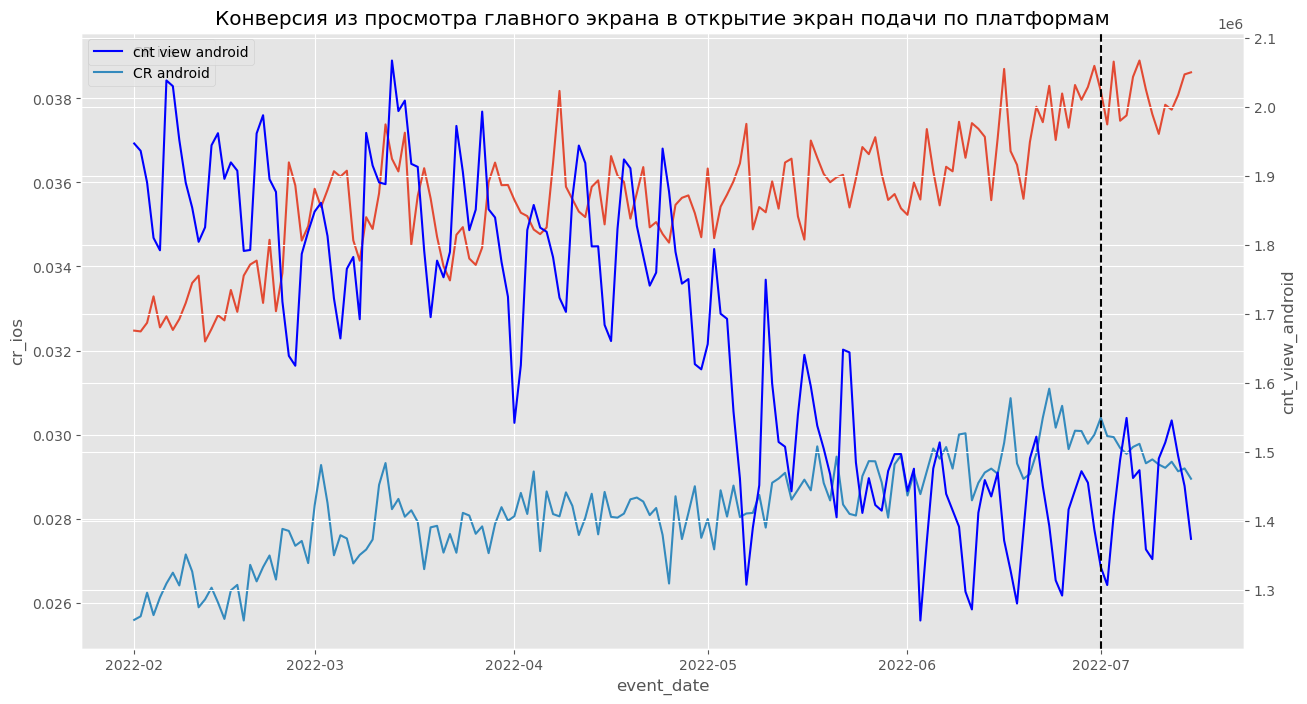

In [ ]:
plt.figure(figsize = (15, 8))
sns.lineplot(y = pivot_data['cr_ios'], x = pivot_data.index, label = 'CR ios')
sns.lineplot(y = pivot_data['cr_android'], x = pivot_data.index, label = 'CR android')
ax2 = plt.twinx()
sns.lineplot(y = pivot_data['cnt_view_android'], x = pivot_data.index , color = 'blue', ax=ax2, label = 'cnt view android')
plt.axvline(x = pd.to_datetime('2022-07-01'), color = 'black', linestyle = '--', label = 'Изменение')
plt.title('Конверсия из просмотра главного экрана в открытие экран подачи по платформам')

## 3) Строим корреляционную матрицу

In [ ]:
corr_df = pivot_data[['cnt_fav_android','cnt_fav_ios','cnt_view_android','cnt_view_ios','cnt_display_phone_android','cnt_display_phone_ios','cr_android','cr_ios']][pivot_data.index < '2022-07-01'].corr()

In [ ]:
corr_df.style.background_gradient(cmap='coolwarm', axis=None)

,cnt_fav_android,cnt_fav_ios,cnt_view_android,cnt_view_ios,cnt_display_phone_android,cnt_display_phone_ios,cr_android,cr_ios
cnt_fav_android,1.000000,0.719666,0.954738,0.876254,0.927072,0.779614,-0.463981,-0.454857
cnt_fav_ios,0.719666,1.000000,0.580466,0.903452,0.609166,0.832568,-0.029146,0.103473
cnt_view_android,0.954738,0.580466,1.000000,0.822030,0.913476,0.660397,-0.704531,-0.635744
cnt_view_ios,0.876254,0.903452,0.822030,1.000000,0.746078,0.794786,-0.368949,-0.331868
cnt_display_phone_android,0.927072,0.609166,0.913476,0.746078,1.000000,0.800585,-0.519268,-0.400352
cnt_display_phone_ios,0.779614,0.832568,0.660397,0.794786,0.800585,1.000000,-0.123136,-0.016359
cr_android,-0.463981,-0.029146,-0.704531,-0.368949,-0.519268,-0.123136,1.000000,0.800127
cr_ios,-0.454857,0.103473,-0.635744,-0.331868,-0.400352,-0.016359,0.800127,1.000000


In [ ]:
# 3.1. достанем 3 наиболее коррелирвоанные ковариаты из датасета
most_correlated_covariates = corr_df['cr_ios'][corr_df['cr_ios'].abs().rank() > len(corr_df)-4].index
print('3.1. Ковариаты наиболее коррелированые с  cr_ios:', most_correlated_covariates.values[:-1])

3.1. Ковариаты наиболее коррелированые с  cr_ios: ['cnt_fav_android' 'cnt_view_android' 'cr_android']


## 4) Causal Impact анализ метрики

In [ ]:
covariates_columns = (most_correlated_covariates.values).tolist()
covariates_columns = covariates_columns[::-1] # задаим порядок нужный для causal impact

# сформируем датасет  с тремя самыми коррелированными ковариатами
ts_data = pivot_data[covariates_columns]
ts_data

,cr_ios,cr_android,cnt_view_android,cnt_fav_android
event_date,,,,
2022-02-01,0.032473,0.025592,1946760,49821
2022-02-02,0.032454,0.025676,1936104,49712
2022-02-03,0.032660,0.026238,1890293,49597
2022-02-04,0.033289,0.025705,1810075,46528
2022-02-05,0.032550,0.026124,1792061,46816
...,...,...,...,...
2022-07-11,0.037846,0.029209,1513556,44210
2022-07-12,0.037730,0.029354,1545732,45374
2022-07-13,0.038080,0.029127,1494189,43521


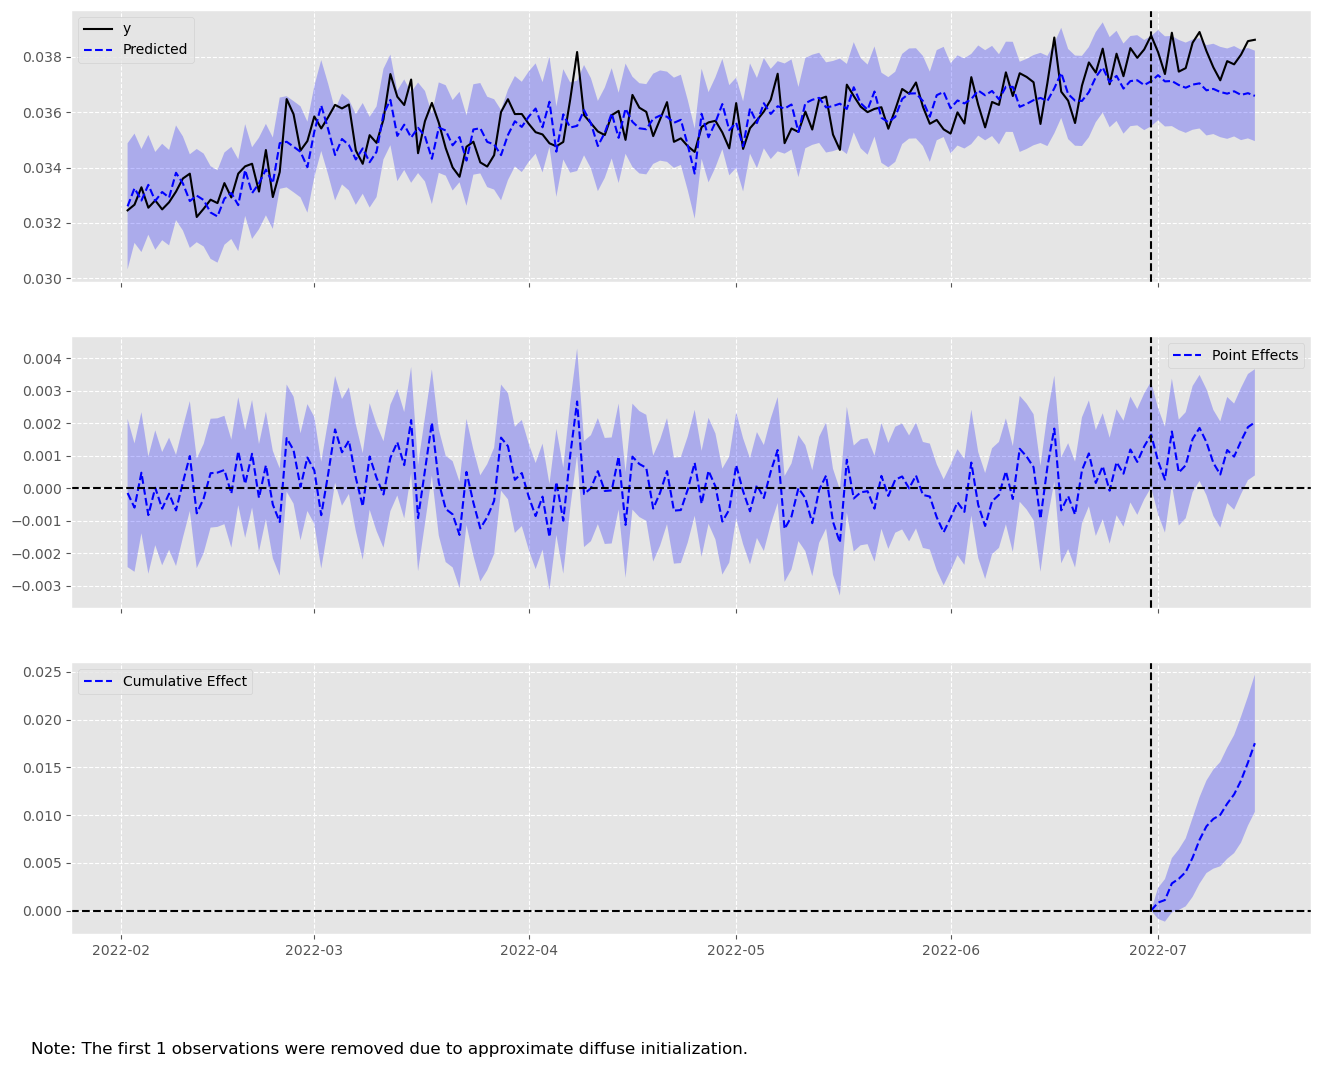

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    0.04               0.57
Prediction (s.d.)         0.04 (0.0)         0.55 (0.0)
95% CI                    [0.04, 0.04]       [0.55, 0.56]

Absolute effect (s.d.)    0.0 (0.0)          0.02 (0.0)
95% CI                    [0.0, 0.0]         [0.01, 0.02]

Relative effect (s.d.)    3.17% (0.66%)      3.17% (0.66%)
95% CI                    [1.87%, 4.47%]     [1.87%, 4.47%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [ ]:
# обучим causal impact
ts_pre_period = ["2022-02-01", "2022-06-30"]
ts_post_period = ["2022-07-01", "2022-07-15"]

ci = CausalImpact(ts_data, ts_pre_period, ts_post_period, alpha = 0.05)
ci.plot(figsize = (16, 12))
print(ci.summary())

In [ ]:
# 4.1. Отвергается ли нулевая гипотеза?
if ci.p_value < 0.05:
    print('4.1. H0 отвергается')
else:
    print('4.1. H0 не отвергается')

4.1. H0 отвергается


In [ ]:
# 4.2. какой относительный размер эффекта выводит модель?
print('4.2.Относительный размер эффекта CI модели =', round(ci.summary_data.loc['rel_effect', :][0], 3))

4.2.Относительный размер эффекта CI модели = 0.032


## 5) Анализ коэффициентов модели

In [ ]:
# проведем анализ коэффициентов модели
ci.trained_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Unobserved Components Results                         
==============================================================================
Dep. Variable:                 cr_ios   No. Observations:                  150
Model:                    local level   Log Likelihood                -131.619
Date:                Mon, 16 Oct 2023   AIC                            273.239
Time:                        14:10:47   BIC                            288.258
Sample:                    02-01-2022   HQIC                           279.341
                         - 06-30-2022                                         
Covariance Type:                  opg                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
sigma2.irregular          0.3265      0.043      7.519      0.000       0.241       0.412
sigma2.level              0.0001      0.000      0.376      0.707      -0.001       0.001
beta.cr_android          -0.5684      0.484     -1.173      0.241      -1.518       0.381
beta.cnt_view_android    -3.9016      1.441     -2.707      0.007      -6.726      -1.077
beta.cnt_fav_android      3.0116      1.168      2.579      0.010       0.723       5.300
===================================================================================
Ljung-Box (L1) (Q):                   4.51   Jarque-Bera (JB):                 2.78
Prob(Q):                              0.03   Prob(JB):                         0.25
Heteroskedasticity (H):               0.84   Skew:                             0.31
Prob(H) (two-sided):                  0.53   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# 5.1. Какие элементы регрессионого уравнения имеют p-value < 0.05
significat_elements = ci.trained_model.pvalues.index[ci.trained_model.pvalues < 0.05].values
print(significat_elements)

['sigma2.irregular' 'beta.cnt_view_android' 'beta.cnt_fav_android']


## 6) Анализ остатков

p-value тест Дики-Фуллера = 0.000000
p-value тест Стьюдента = 0.121894
p-value тест Льюнга-Бокса = 0.033779


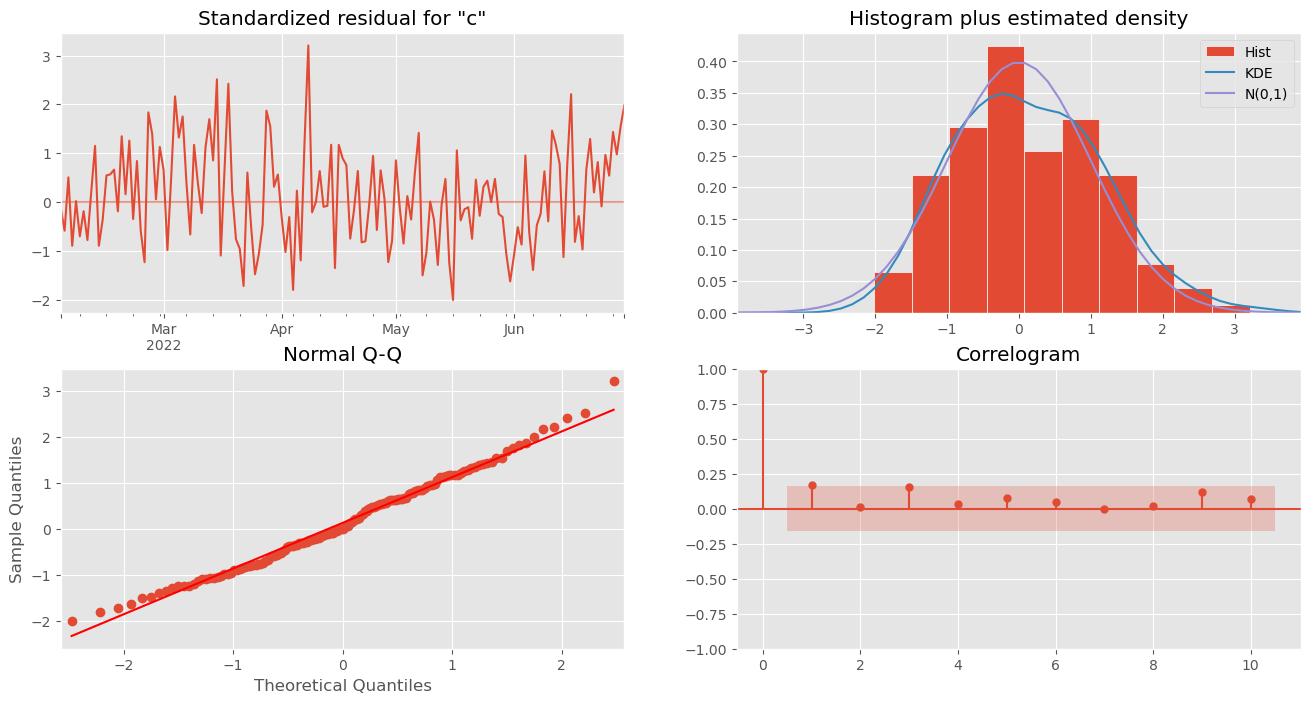

In [ ]:
# проанализируем остатки полученной модели
p_val_df = sm.tsa.stattools.adfuller(ci.trained_model.resid)[1]
p_val_st = ttest_1samp(ci.trained_model.resid, 0)[1]
p_val_lb = ci.trained_model.test_serial_correlation('ljungbox')[0, :, 0][1]

print("p-value тест Дики-Фуллера = %f" % p_val_df)
print("p-value тест Стьюдента = %f" % p_val_st)
print("p-value тест Льюнга-Бокса = %f" % p_val_lb)
ci.trained_model.plot_diagnostics(figsize = (16, 8));

In [ ]:
# 6.1. Укажите верные утверждения по 3 гипотезам относително остатков
if p_val_df < 0.05:
    print('H0 для критерия Дики-Фуллера отвергается -> остатки стационарны')
else:
    print('H0 для критерия Дики-Фуллера НЕ отвергается -> остатки НЕ стационарны')

print('-------------------------')

if p_val_st < 0.05:
    print('H0 для t-критерия отвергается -> остатки смещены')
else:
    print('H0 для t-критерия НЕ отвергается -> остатки НЕ смещены')

print('-------------------------')

if p_val_lb < 0.05:
    print('H0 для критерия Льюнга-Бокса отвергается Льюнга-Бокса -> остатки автокоррелированы')
else:
    print('H0 для критерия Льюнга-Бокса НЕ отвергается Льюнга-Бокса, остатки НЕ автокоррелированы')

H0 для критерия Дики-Фуллера отвергается -> остатки стационарны
-------------------------
H0 для t-критерия НЕ отвергается -> остатки НЕ смещены
-------------------------
H0 для критерия Льюнга-Бокса отвергается Льюнга-Бокса -> остатки автокоррелированы


### 7) Ответ, оценка MAE, MAPE, R2_score для предсказании исторических данных

In [ ]:
# 7.1. Укажите метрики оценки на зафиттенных данных
ci_data = ci.data.merge(ci.inferences, left_index = True, right_index = True)
ci_data_pre = ci_data.loc[ts_pre_period[0]:ts_pre_period[-1], :]

mae = mean_absolute_error(ci_data_pre.cr_ios, ci_data_pre.preds)
mape = mean_absolute_percentage_error(ci_data_pre.cr_ios, ci_data_pre.preds)
r2_score = r2_score(ci_data_pre.cr_ios, ci_data_pre.preds)

print('7.1. Укажите метрики оценки на зафиттенных данных:')
print('MAE =', round(mae, 3))
print('MAPE =', round(mape, 3))
print('R2_score =', round(r2_score, 3))

7.1. Укажите метрики оценки на зафиттенных данных:
MAE = 0.001
MAPE = 0.019
R2_score = 0.663


## 8) Оценим мощность и статзначимость Causal Impact в нашем конкретном кейсе
Для симуляции будем использовать следующие вводные
**- используемые ковариаты:**
- три ковариаты с предыдущего анализа (имеющие наилучщую корреляцию с целевой метрикой
- кол-во дней в условном эксперименте - 14 (n_days = 14 в функции из лекции)
- доля дат зарезервированных под контроль - 0.6
- кол-во симуляций для одной комбинации = 30 (sample_n = 30 в функции из лекции)
- Перед стартом функции обозначте np.random.seed(1)

In [ ]:
import joblib

def causal_analysis(data, target_value, covariate, n_days = 14, control_percent = 0.6, sample_n = 30):
    '''
    data - исторические данные на которых мы оцениваем ковариату
    covariate - назвние столбца ковариат
    n_days - период в днях на post период
    control_percent - доля датасета зарезервированного под pre период (0.1)
    sample_n - кол-во симуляций

    '''
    n_days -= 1

    data = pd.concat([data.loc[:, [target_value]], data.loc[:, covariate]], axis = 1)

    df_copy = data.copy()
    effects = [0.9, 0.95, 0.975, 1., 1.025, 1.05, 1.1] # Эффекты
    rel_effects = []

    #dates = pd.DataFrame(data.index, columns = ['post_period_0']) # Даты
    dates = pd.DataFrame({'post_period_0': data.index}) # Даты

    # Самая первая дата контрольной группы
    initial = dates.values[0][0]
    # Тестовая группа, подбираем из неё 10 рандомных дат
    test = dates.iloc[int(len(dates)*(control_percent)):-n_days]\
                .sample(sample_n, random_state = 123, replace = True)\
    # Определяем пост и пре период
    test['post_period_1'] = test.post_period_0 + pd.DateOffset(days = n_days)
    test['pre_period_0'] = initial
    test['pre_period_1'] = test.post_period_0 - pd.DateOffset(days = 1)

    test = test.astype(str)
    a = np.empty((sample_n, len(effects) + 2))

    def calculate_sse_mape_pval(d):
        sse = []
        mape = []
        p_vals = []
        for i in range(len(effects)):
            pre_period = [test.pre_period_0.values[d], test.pre_period_1.values[d]]
            post_period = [test.post_period_0.values[d], test.post_period_1.values[d]]

            df_copy = data.copy() # создаём другую переменную дубликата датафрейма чтобы каждый раз задавать новый эффект

            df_copy.loc[np.logical_and(
                        df_copy.index >= post_period[0], df_copy.index <= post_period[1]), target_value] *= effects[i] # задаём эффект
            ci = CausalImpact(df_copy, pre_period, post_period)

            relative_eff = ci.summary_data.loc['rel_effect', :][0].round(3)
            real_eff = effects[i] - 1
            to_sse = pow(relative_eff - real_eff, 2)
            to_mape = abs(relative_eff - real_eff) * 100

            sse.append(to_sse)
            mape.append(to_mape)
            rel_effects.append(relative_eff)
            p_vals.append(ci.p_value)
        return (d, sum(sse), np.mean(mape), p_vals[effects.index(1)], p_vals[effects.index(1.025)],
               p_vals[effects.index(0.975)], p_vals[effects.index(1.05)], p_vals[effects.index(0.95)],
               p_vals[effects.index(1.1)], p_vals[effects.index(0.9)])

    results = joblib.Parallel(n_jobs=-1, verbose = len(test))(joblib.delayed(calculate_sse_mape_pval)(d) for d in range(len(test)))

    for result in results:
        d = result[0]
        a[d][0] = result[1]
        a[d][1] = result[2]
        a[d][2] = result[3]
        a[d][3] = result[4]
        a[d][4] = result[5]
        a[d][5] = result[6]
        a[d][6] = result[7]
        a[d][7] = result[8]
        a[d][8] = result[9]

    aa = pd.DataFrame(a, columns = ['sse', 'mape', 'p_val_1', 'p_val_1_025', 'p_val_0_975',
                                    'p_val_1_05', 'p_val_0_95', 'p_val_1_1', 'p_val_0_9'])
    final = test.reset_index().merge(aa.reset_index(), left_index = True, right_index = True)
    final.drop(columns = ['index_x', 'index_y'], inplace = True)
    final['covariate'] = ', '.join(covariate)
    return final

In [ ]:
# оставим только исторические данные
ts_data_pre = ts_data.query("event_date < '2022-07-01'")
ts_data_pre

,cr_ios,cr_android,cnt_view_android,cnt_fav_android
event_date,,,,
2022-02-01,0.032473,0.025592,1946760,49821
2022-02-02,0.032454,0.025676,1936104,49712
2022-02-03,0.032660,0.026238,1890293,49597
2022-02-04,0.033289,0.025705,1810075,46528
2022-02-05,0.032550,0.026124,1792061,46816
...,...,...,...,...
2022-06-26,0.037302,0.029655,1416714,42012
2022-06-27,0.038317,0.030092,1444684,43474
2022-06-28,0.037965,0.030084,1472137,44288


In [ ]:
# создадим комбинации ковариат для перебора в ts_data
column_combinations = []
for i in range(1, len(ts_data_pre.columns[1:]) + 1):
    column_combinations.extend(list(combinations(ts_data_pre.columns[1:], i)))
column_combinations

[('cr_android',),
 ('cnt_view_android',),
 ('cnt_fav_android',),
 ('cr_android', 'cnt_view_android'),
 ('cr_android', 'cnt_fav_android'),
 ('cnt_view_android', 'cnt_fav_android'),
 ('cr_android', 'cnt_view_android', 'cnt_fav_android')]

In [ ]:
%%time
# запустим симуляцию для проверки мощности и статзначимости
res = pd.DataFrame()
np.random.seed(1)
for comb in column_combinations:
    caus = causal_analysis(ts_data_pre, 'cr_ios', comb, 14, 0.7, 50)
    res = pd.concat([res, caus], axis = 0)
res

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  3

[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  6.7min remaining:   25.5s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  6.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   36.8s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   36.9s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:   37.3s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   38.1s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   38.5s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:   38.6s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:   38.9s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   39.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 

[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed:  5.0min remaining:   49.2s
[Parallel(n_jobs=-1)]: Done  45 out of  50 | elapsed:  5.2min remaining:   34.3s
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  5.2min remaining:   19.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  6.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed

,post_period_0,post_period_1,pre_period_0,pre_period_1,sse,mape,p_val_1,p_val_1_025,p_val_0_975,p_val_1_05,p_val_0_95,p_val_1_1,p_val_0_9,covariate
0,2022-06-16,2022-06-29,2022-02-01,2022-06-15,0.000588,0.914286,0.113886,0.00000,0.011988,0.0,0.0,0.0,0.0,cr_android
1,2022-05-30,2022-06-12,2022-02-01,2022-05-29,0.000467,0.814286,0.116883,0.00999,0.000000,0.0,0.0,0.0,0.0,cr_android
2,2022-06-16,2022-06-29,2022-02-01,2022-06-15,0.000588,0.914286,0.084915,0.00000,0.016983,0.0,0.0,0.0,0.0,cr_android
3,2022-05-19,2022-06-01,2022-02-01,2022-05-18,0.000048,0.257143,0.364635,0.00000,0.000999,0.0,0.0,0.0,0.0,cr_android
4,2022-06-14,2022-06-27,2022-02-01,2022-06-13,0.000166,0.485714,0.245754,0.00000,0.002997,0.0,0.0,0.0,0.0,cr_android
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,2022-05-20,2022-06-02,2022-02-01,2022-05-19,0.000304,0.657143,0.170829,0.00000,0.003996,0.0,0.0,0.0,0.0,"cr_android, cnt_view_android, cnt_fav_android"
46,2022-06-14,2022-06-27,2022-02-01,2022-06-13,0.004195,2.442857,0.000000,0.00000,0.417582,0.0,0.0,0.0,0.0,"cr_android, cnt_view_android, cnt_fav_android"
47,2022-06-14,2022-06-27,2022-02-01,2022-06-13,0.004195,2.442857,0.000999,0.00000,0.444555,0.0,0.0,0.0,0.0,"cr_android, cnt_view_android, cnt_fav_android"
48,2022-06-06,2022-06-19,2022-02-01,2022-06-05,0.002648,1.942857,0.005994,0.00000,0.163836,0.0,0.0,0.0,0.0,"cr_android, cnt_view_android, cnt_fav_android"


In [ ]:
# аггрегируем полученые данные
def to_res(data, to_group, n, alpha = 0.05):
    def p_val_count_alpha(p_val):
        return np.count_nonzero(p_val < alpha)

    def p_val_count_beta(p_val):
        return np.count_nonzero(p_val >= alpha)

    p_val_cols = data.filter(like = 'p_val').columns

    data['pre_period_diff'] = (pd.to_datetime(data.pre_period_1) - pd.to_datetime(data.pre_period_0))
    res = data.groupby([to_group]).agg({'sse': 'sum',
                                     'mape': 'mean',
                                     p_val_cols[0]: p_val_count_alpha,
                                     p_val_cols[1]: p_val_count_beta,
                                     p_val_cols[2]: p_val_count_beta,
                                     p_val_cols[3]: p_val_count_beta,
                                     p_val_cols[4]: p_val_count_beta,
                                     p_val_cols[5]: p_val_count_beta,
                                     p_val_cols[6]: p_val_count_beta,
                                     'pre_period_diff': 'mean'})

    res[p_val_cols[0]] = res[p_val_cols[0]] / n
    res[p_val_cols[1]] = res[p_val_cols[1]] / n
    res[p_val_cols[2]] = res[p_val_cols[2]] / n
    res[p_val_cols[3]] = res[p_val_cols[3]] / n
    res[p_val_cols[4]] = res[p_val_cols[4]] / n
    res[p_val_cols[5]] = res[p_val_cols[5]] / n
    res[p_val_cols[6]] = res[p_val_cols[6]] / n

    return res

In [ ]:
res_conc = to_res(res, 'covariate', 50)
res_conc

,sse,mape,p_val_1,p_val_1_025,p_val_0_975,p_val_1_05,p_val_0_95,p_val_1_1,p_val_0_9,pre_period_diff
covariate,,,,,,,,,,
cnt_fav_android,0.232807,2.410000,0.78,0.00,0.94,0.0,0.1,0.0,0.0,118 days 10:33:36
cnt_view_android,0.061568,1.012571,0.28,0.00,0.30,0.0,0.0,0.0,0.0,118 days 10:33:36
"cnt_view_android, cnt_fav_android",0.023130,0.705143,0.20,0.04,0.00,0.0,0.0,0.0,0.0,118 days 10:33:36
cr_android,0.012678,0.509714,0.00,0.00,0.00,0.0,0.0,0.0,0.0,118 days 10:33:36
"cr_android, cnt_fav_android",0.025875,0.735143,0.16,0.12,0.00,0.0,0.0,0.0,0.0,118 days 10:33:36
"cr_android, cnt_view_android",0.026450,0.746286,0.16,0.10,0.00,0.0,0.0,0.0,0.0,118 days 10:33:36
"cr_android, cnt_view_android, cnt_fav_android",0.116603,1.595714,0.58,0.00,0.56,0.0,0.0,0.0,0.0,118 days 10:33:36


**8.1. Какая комбинация ковариат дает лучшие уровни ошибок первого и второго рода?**
- комбинация всех трех метрик с наилучшимим значениями корреляции с целевой метрики
- **аналогичная целевая метрика в android** - правильный вариант
- сумма просмотров объявлений в android и сумма добавлений в избранное в андроид

In [ ]:
# 8.2 Чему равна ошибка первого рода в симуляции по наилучшей комбинации ковариат?
print('Ошибка I рода для  =', res_conc.p_val_1['cr_android'])

Ошибка I рода = 0.0
